In [271]:
from fredapi import Fred
from dotenv import load_dotenv
import os
import pandas as pd
import numpy as np

load_dotenv()
api_key = os.getenv("FRED_API_KEY")
fred = Fred(api_key=api_key)

series = {
    "unemployment_rate": "UNRATE",
    "labor_force_participation_rate": "CIVPART",
    "initial_jobless_claims": "IC4WSA",
    "nonfarm_payroll_employment": "PAYEMS",
    "employment_population_ratio": "EMRATIO",
    "consumer_price_index": "CPIAUCSL",
    "core_consumer_price_index": "CPILFESL",
    "personal_consumption_expenditures_price_index": "PCEPI",
    "federal_funds_rate": "FEDFUNDS",
    "ten_year_treasury_yield": "DGS10",
    "two_year_treasury_yield": "DGS2",
    "industrial_production_index": "INDPRO",
    "retail_sales": "RSAFS",
    "housing_starts": "HOUST",
    "sp500_index": "SP500",
    "gdp": "GDPC1"
}

Start by configuring FRED API credentials and listing out the features we'll use to model unemployment rate.

In [272]:
raw_df = pd.DataFrame()

for name, code in series.items():
    s = fred.get_series(code)
    raw_df[name] = s

raw_df.head()

,unemployment_rate,labor_force_participation_rate,initial_jobless_claims,nonfarm_payroll_employment,employment_population_ratio,consumer_price_index,core_consumer_price_index,personal_consumption_expenditures_price_index,federal_funds_rate,ten_year_treasury_yield,two_year_treasury_yield,industrial_production_index,retail_sales,housing_starts,sp500_index,gdp
1948-01-01,3.4,58.6,NaN,44679.0,56.6,23.68,NaN,NaN,NaN,NaN,NaN,14.3524,NaN,NaN,NaN,2239.682
1948-02-01,3.8,58.9,NaN,44533.0,56.7,23.67,NaN,NaN,NaN,NaN,NaN,14.3793,NaN,NaN,NaN,NaN
1948-03-01,4.0,58.5,NaN,44683.0,56.1,23.50,NaN,NaN,NaN,NaN,NaN,14.2177,NaN,NaN,NaN,NaN
1948-04-01,3.9,59.0,NaN,44379.0,56.7,23.82,NaN,NaN,NaN,NaN,NaN,14.2447,NaN,NaN,NaN,2276.690
1948-05-01,3.5,58.3,NaN,44796.0,56.2,24.01,NaN,NaN,NaN,NaN,NaN,14.4870,NaN,NaN,NaN,NaN


Pull data from FRED API.

In [273]:
raw_df.isna().mean().sort_values(ascending=False)

sp500_index                                      0.918172
initial_jobless_claims                           0.891605
gdp                                              0.667375
two_year_treasury_yield                          0.591923
retail_sales                                     0.561105
ten_year_treasury_yield                          0.476089
housing_starts                                   0.140276
personal_consumption_expenditures_price_index    0.140276
core_consumer_price_index                        0.115834
federal_funds_rate                               0.082891
unemployment_rate                                0.001063
consumer_price_index                             0.001063
labor_force_participation_rate                   0.001063
employment_population_ratio                      0.001063
nonfarm_payroll_employment                       0.000000
industrial_production_index                      0.000000
dtype: float64

Looks like we have a ton of missing values. Let's investigate the causes of this 'missingness' - we could be dealing with data reported at a different frequency (e.g. quarterly instead of annually) or perhaps certain metrics only started being recorded later on (e.g. 1960's instead of in 1948).

In [274]:
raw_df.apply(lambda col: col.first_valid_index()).sort_values()

unemployment_rate                               1948-01-01
labor_force_participation_rate                  1948-01-01
nonfarm_payroll_employment                      1948-01-01
employment_population_ratio                     1948-01-01
consumer_price_index                            1948-01-01
industrial_production_index                     1948-01-01
gdp                                             1948-01-01
federal_funds_rate                              1954-07-01
core_consumer_price_index                       1957-01-01
personal_consumption_expenditures_price_index   1959-01-01
housing_starts                                  1959-01-01
ten_year_treasury_yield                         1962-02-01
initial_jobless_claims                          1967-04-01
two_year_treasury_yield                         1976-06-01
retail_sales                                    1992-01-01
sp500_index                                     2016-07-01
dtype: datetime64[us]

Looking at where each field has it's first valid entry:
1. sp500_index, retail_sales don't have valid values until 1992/2016 respectively, we will remove these variables
2. initial_jobless_claims is missing in about 89% of rows which makes it functionally unusable - we will also remove this variable

Removing those three sparse, unusable variables leaves us with three variables with many missing values (>40%)
1. gdp
2. ten_year_treasury_yield
3. two_year_treasury_yield

In [275]:
def print_index_gaps(df, columns):
    """
    Prints column names and the distribution of index time gaps between observations.
    """
    for col in columns:
        print(col)

        s = df[col].dropna()
        diffs = s.index.to_series().diff().value_counts()

        print(diffs.head())
        print()

print_index_gaps(raw_df, ['gdp', 'ten_year_treasury_yield', 'two_year_treasury_yield'])

gdp
92 days    156
91 days     98
90 days     58
Name: count, dtype: int64

ten_year_treasury_yield
61 days    134
31 days    126
30 days    101
62 days     54
28 days     35
Name: count, dtype: int64

two_year_treasury_yield
61 days    103
31 days     97
30 days     80
62 days     43
28 days     27
Name: count, dtype: int64



We suspect gdp nulls may be attributed to quarterly reporting (instead of monthly). We also want to investigate if there are patterns to missing values for the treasury yield variables. Lets use 'print_index_gaps' for this analysis.

1. gdp observations are spaced out between 90-92 days, quarterly reporting. We can forward fill these values - as GDP is only known when released each quarter - between releases the latest values is the current best estimate.
2. ten_year_treasury_yield/two_year_treasury_yield look to be reported monthly with some missing months. We can use time interpolation here by making a market assumption of smooth curves between observations. We could also foward fill these as well.

In [276]:
df = raw_df.copy()

# Ensure datetime index
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# Drop unwanted columns (ignore errors in case any are missing)
df = df.drop(
    columns=[
        "sp500_index",
        "retail_sales",
        "initial_jobless_claims"
    ],
    errors="ignore"
)

# GDP: forward fill
gdp_q = df['gdp'].dropna()
gdp_growth_q = np.log(gdp_q).diff()

df['gdp_growth'] = gdp_growth_q.reindex(df.index, method='ffill')

# Treasury yields: time interpolation
df['ten_year_treasury_yield'] = df['ten_year_treasury_yield'].interpolate(method='time')
df['two_year_treasury_yield'] = df['two_year_treasury_yield'].interpolate(method='time')

# Keep only 1959-01-01 onward
df = df.loc[df.index >= "1959-01-01"]

Here let's drop those unusable columns and implement the data cleaning decisions made above

In [277]:
print(df.apply(lambda col: col.first_valid_index()).sort_values())
print(df.isna().mean().sort_values(ascending=False))

unemployment_rate                               1959-01-01
labor_force_participation_rate                  1959-01-01
nonfarm_payroll_employment                      1959-01-01
employment_population_ratio                     1959-01-01
consumer_price_index                            1959-01-01
core_consumer_price_index                       1959-01-01
personal_consumption_expenditures_price_index   1959-01-01
federal_funds_rate                              1959-01-01
industrial_production_index                     1959-01-01
housing_starts                                  1959-01-01
gdp                                             1959-01-01
gdp_growth                                      1959-01-01
ten_year_treasury_yield                         1962-02-01
two_year_treasury_yield                         1976-06-01
dtype: datetime64[us]
gdp                                              0.667491
two_year_treasury_yield                          0.258344
ten_year_treasury_yield             

Sanity check to ensure we have valid data starting from 1959 (with the exception of the treasury yields which started being recorded later). Note we still have unaccounted null values for five variables:
1. employment_population_ratio
2. labor_force_participation_rate
3. unemployment_rate
4. core_consumer_price_index
5. consumer_price_index

All of these variables have only 0.1236% of their values missing, which is relatively insignificant but still worth investigating.

In [278]:
for col in ['employment_population_ratio', 'labor_force_participation_rate', 'unemployment_rate', 'core_consumer_price_index', 'consumer_price_index']:
    if df[col].isna().any():
        print(df[df[col].isna()][col])

pos = df.index.get_loc("2025-10-01")
df.iloc[pos-2:pos+3]

2025-10-01   NaN
Name: employment_population_ratio, dtype: float64
2025-10-01   NaN
Name: labor_force_participation_rate, dtype: float64
2025-10-01   NaN
Name: unemployment_rate, dtype: float64
2025-10-01   NaN
Name: core_consumer_price_index, dtype: float64
2025-10-01   NaN
Name: consumer_price_index, dtype: float64


,unemployment_rate,labor_force_participation_rate,nonfarm_payroll_employment,employment_population_ratio,consumer_price_index,core_consumer_price_index,personal_consumption_expenditures_price_index,federal_funds_rate,ten_year_treasury_yield,two_year_treasury_yield,industrial_production_index,housing_starts,gdp,gdp_growth
2025-08-01,4.3,62.3,158472.0,59.6,323.291,329.700,127.293,4.33,4.230000,3.690000,101.6247,1291.0,NaN,0.010706
2025-09-01,4.4,62.5,158548.0,59.7,324.245,330.418,127.625,4.22,4.174098,3.618852,101.6680,1319.0,NaN,0.010706
2025-10-01,NaN,NaN,158408.0,NaN,NaN,NaN,127.871,4.09,4.120000,3.550000,101.2195,1273.0,24055.749,0.001203
2025-11-01,4.5,62.5,158449.0,59.6,325.063,331.043,128.152,3.88,4.104754,3.544918,101.0344,1319.0,NaN,0.001203
2025-12-01,4.4,62.4,158432.0,59.7,326.031,331.814,128.576,3.72,4.090000,3.540000,101.4941,1378.0,NaN,0.001203


All missing values are in the row for October of 2025. Looking at the values for that row, it seems reasonable to interpolate them because of how steady those values are. Another, safer in many cases, method would just to be to drop the row.

In [279]:
df['unemployment_rate'] = df['unemployment_rate'].interpolate(method='time')
df['labor_force_participation_rate'] = df['labor_force_participation_rate'].interpolate(method='time')
df['employment_population_ratio'] = df['employment_population_ratio'].interpolate(method='time')
df['consumer_price_index'] = df['consumer_price_index'].interpolate(method='time')
df['core_consumer_price_index'] = df['core_consumer_price_index'].interpolate(method='time')

Now let's do some EDA before getting to the modeling.

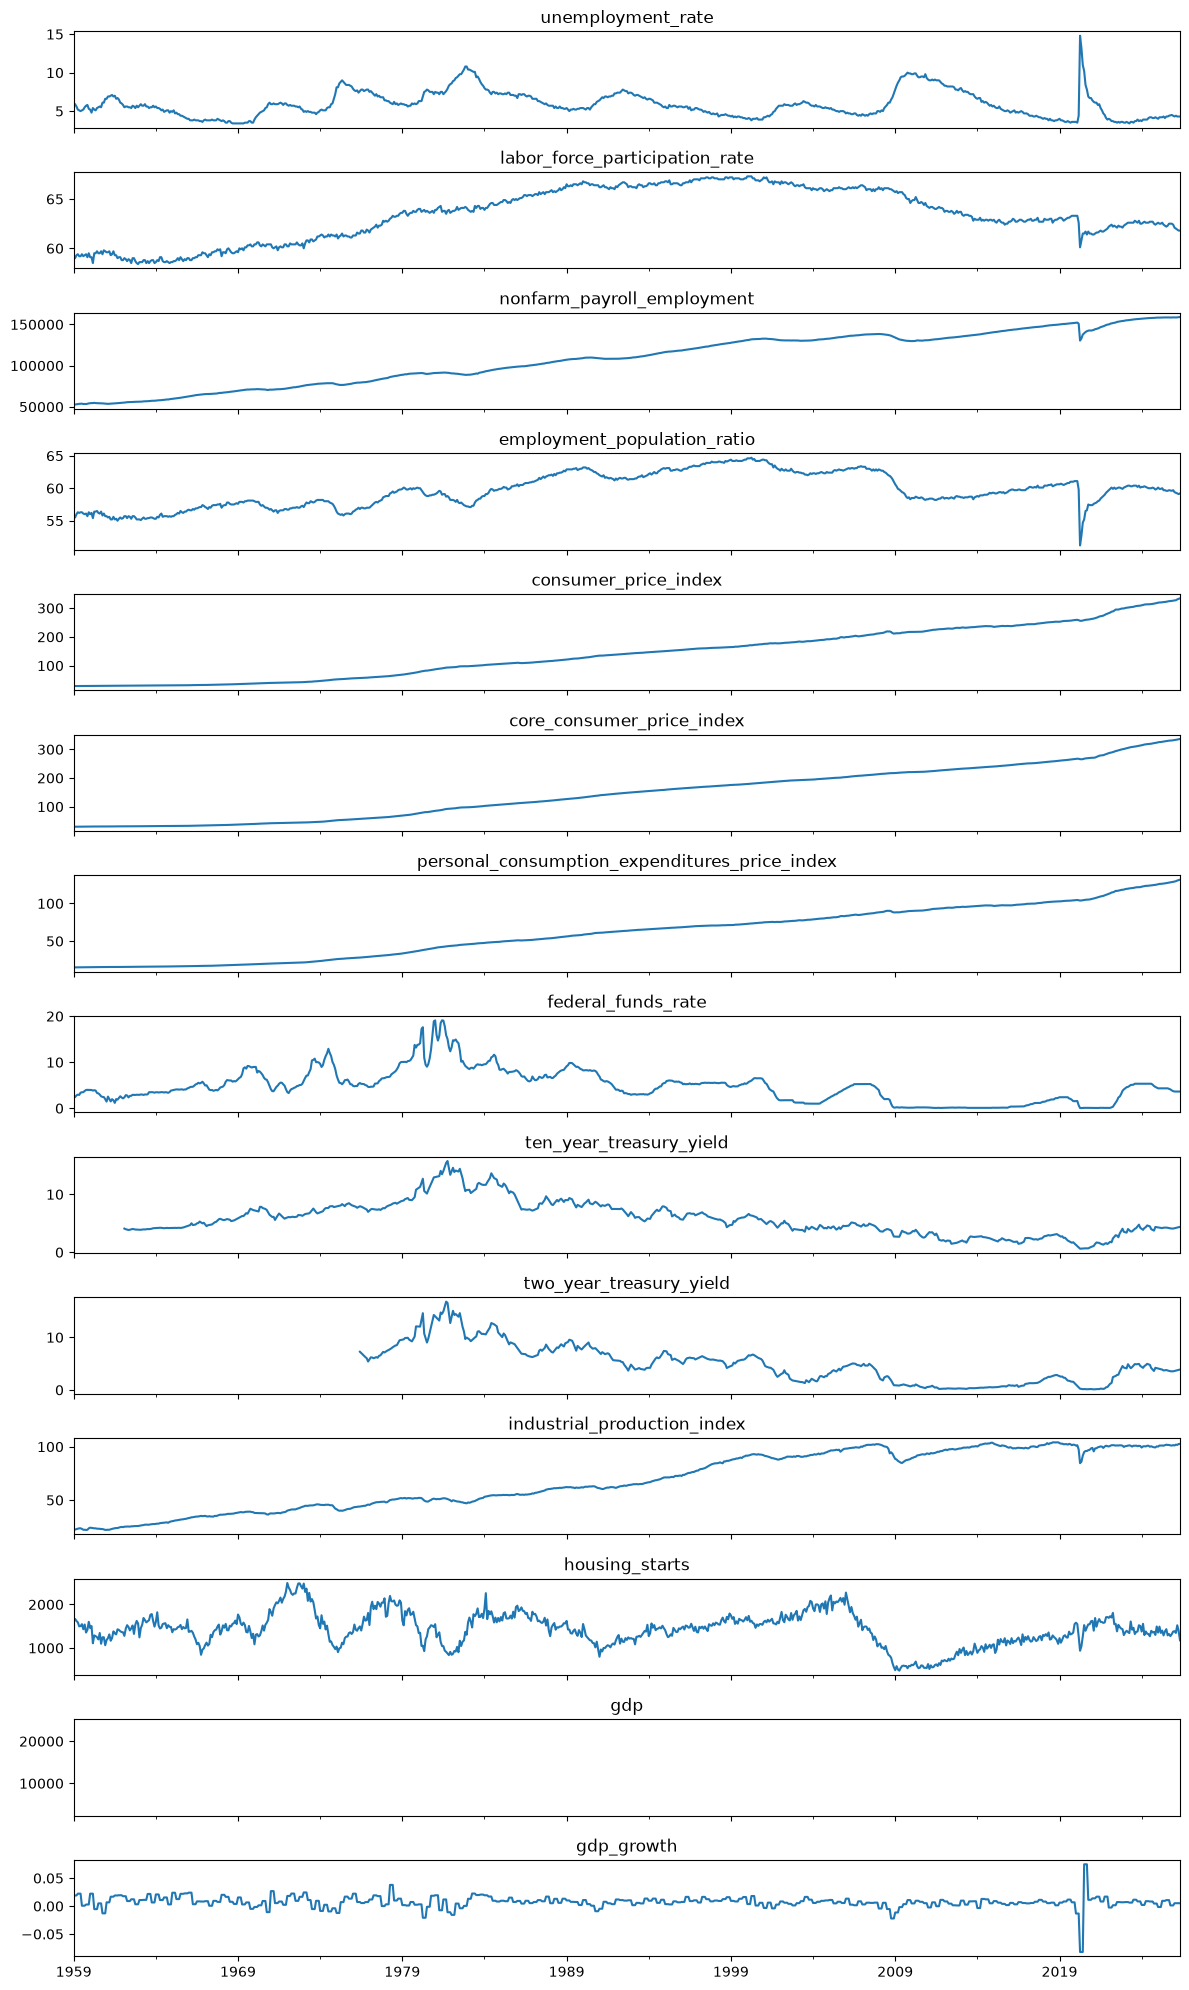

In [280]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(df.columns), 1, figsize=(12, 20), sharex=True)

for ax, col in zip(axes, df.columns):
    df[col].plot(ax=ax)
    ax.set_title(col)

plt.tight_layout()

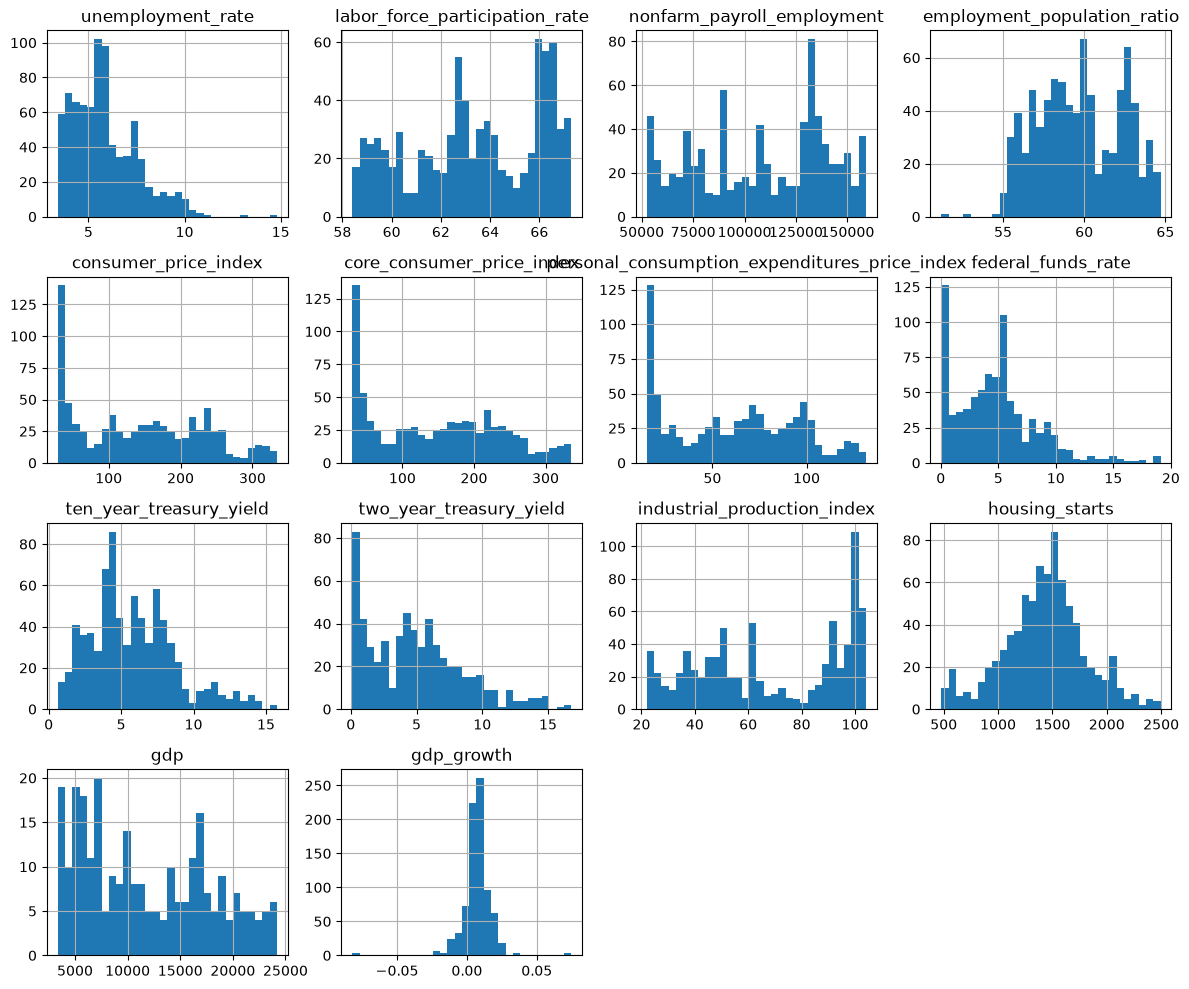

In [281]:
df.hist(figsize=(12,10), bins=30)
plt.tight_layout()

Looking at the distributions of the variables, the following seem to have right skews and would benefit from a log diff transformation:
1. nonfarm_payroll_employment
2. consumer_price_index
3. core_consumer_price_index
4. personal_consumption_expenditures_price_index
5. industrial_production_index

These represent economic quantities that 'naturally' grow over time that may be non-stationary.

In [282]:
# Apply log diff transforms
df["nonfarm_payroll_employment_growth"] = np.log(df["nonfarm_payroll_employment"]).diff()
df["cpi_growth"] = np.log(df["consumer_price_index"]).diff()
df["core_consumer_price_index_growth"] = np.log(df["core_consumer_price_index"]).diff()
df["personal_consumption_expenditures_price_index_growth"] = np.log(df["personal_consumption_expenditures_price_index"]).diff()
df["industrial_production_index_growth"] = np.log(df["industrial_production_index"]).diff()

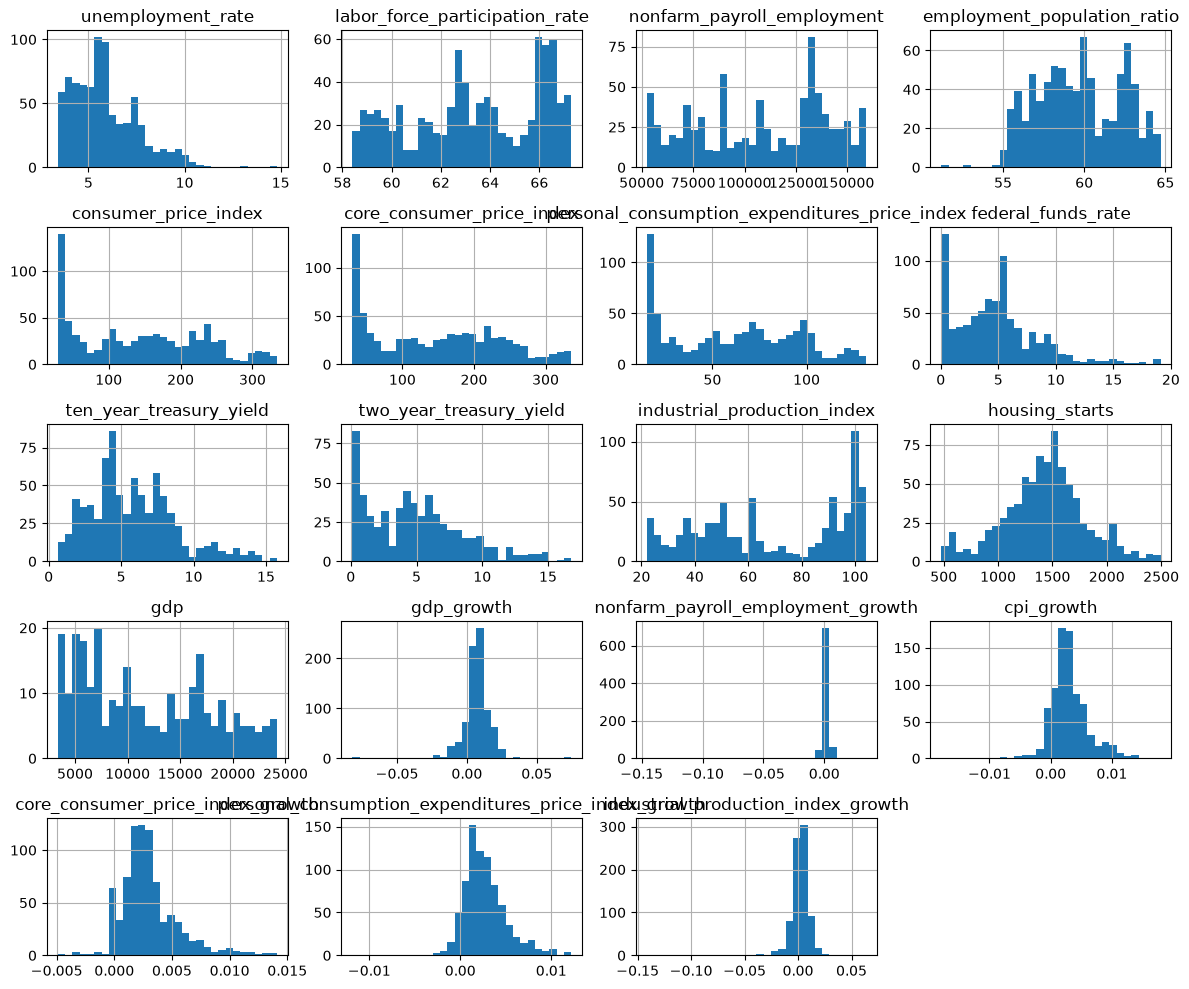

In [283]:
df.hist(figsize=(12,10), bins=30)
plt.tight_layout()

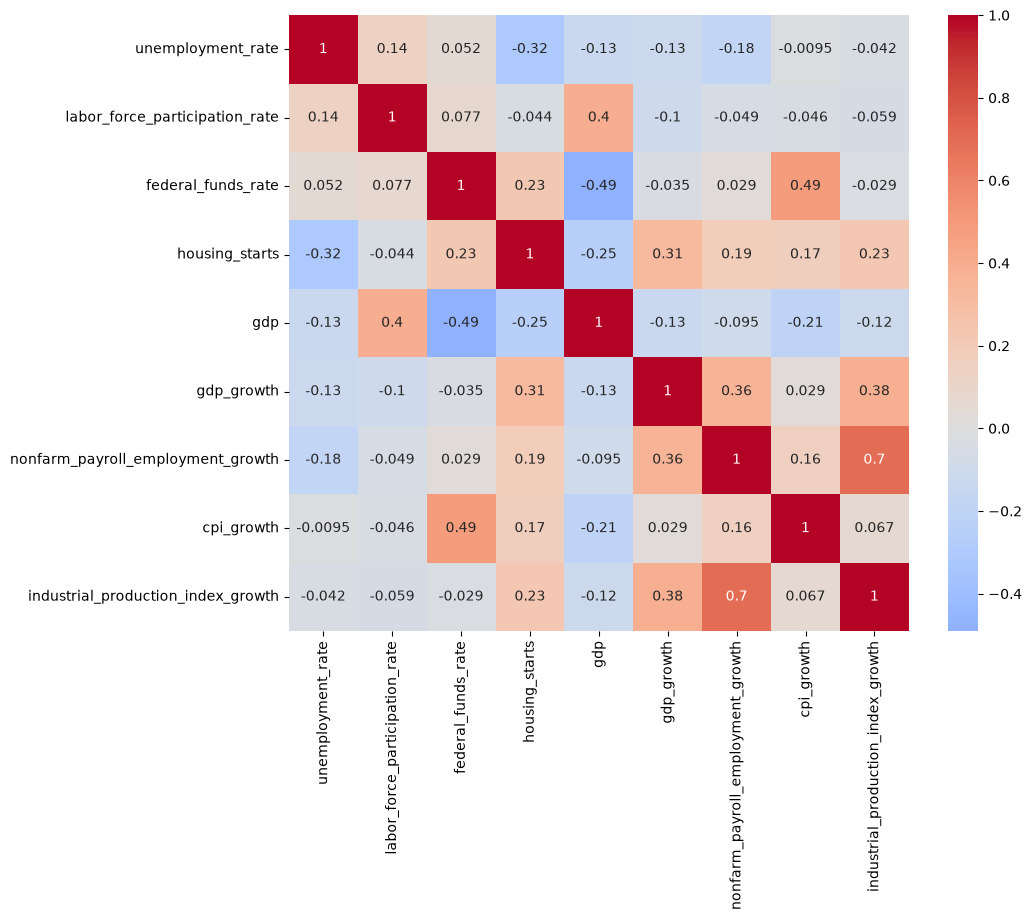

In [284]:
import seaborn as sns

df = df.drop(columns=["nonfarm_payroll_employment", "employment_population_ratio", # Tightly coupled with labor_force_participation_rate
                                "consumer_price_index", "core_consumer_price_index", "personal_consumption_expenditures_price_index", # Dropping these for the CPI growth indexes
                                "industrial_production_index", # Dropping for the growth indexes
                                "core_consumer_price_index_growth", "personal_consumption_expenditures_price_index_growth", # Tightly coupled with cpi_growth, don't need all three
                                "two_year_treasury_yield", "ten_year_treasury_yield", # Tightly coupled with federal_funds_rate
                                ])

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", center=0)
plt.show()

In [285]:
from statsmodels.tsa.stattools import adfuller

# Augmented Dickey-Fuller (ADF) Test
# Low p-value suggests the series is stationary (properties do not change over time)
for col in df.columns:
    result = adfuller(df[col].dropna())
    print(f"{col}: p-value = {result[1]:.4f}")

unemployment_rate: p-value = 0.0099
labor_force_participation_rate: p-value = 0.5377
federal_funds_rate: p-value = 0.0403
housing_starts: p-value = 0.0025
gdp: p-value = 1.0000
gdp_growth: p-value = 0.0000
nonfarm_payroll_employment_growth: p-value = 0.0000
cpi_growth: p-value = 0.0245
industrial_production_index_growth: p-value = 0.0000


It appears that labor_force_participation_rate is non-stationary. Lets diff it. We'll also drop gdp in favor of gdp_growth.

In [286]:
df["lfpr_diff"] = df["labor_force_participation_rate"].diff()

df = df.drop(columns=["labor_force_participation_rate", "gdp"])
df = df.rename(columns={
    "lfpr_diff": "labor_force_participation_rate_change"
})
# Augmented Dickey-Fuller Test Again
for col in df.columns:
    result = adfuller(df[col].dropna())
    print(f"{col}: p-value = {result[1]:.4f}")

unemployment_rate: p-value = 0.0099
federal_funds_rate: p-value = 0.0403
housing_starts: p-value = 0.0025
gdp_growth: p-value = 0.0000
nonfarm_payroll_employment_growth: p-value = 0.0000
cpi_growth: p-value = 0.0245
industrial_production_index_growth: p-value = 0.0000
labor_force_participation_rate_change: p-value = 0.0000


Great! Now that our data is stationary let's calculate lags - so we use last month's economic conditions to make predictions.

We will have horizons 1, 3, 6 months for our predictions. As well as lags 1, 2, 3, 6 months to represent the delayed effect economic features may have on unemployment.

In [ ]:
import numpy as np
import pandas as pd

model_df = df.copy().sort_index()

# =========================================================
# 1. TARGETS
# =========================================================
model_df["y_1"]  = model_df["unemployment_rate"].shift(-1)
model_df["y_3"]  = model_df["unemployment_rate"].shift(-3)
model_df["y_6"]  = model_df["unemployment_rate"].shift(-6)
model_df["y_12"] = model_df["unemployment_rate"].shift(-12)


# =========================================================
# 2. PERSISTENCE
# =========================================================
model_df["unemp_level"] = model_df["unemployment_rate"]
model_df["unemp_ma3"]   = model_df["unemployment_rate"].rolling(3).mean()
model_df["unemp_ma6"]   = model_df["unemployment_rate"].rolling(6).mean()


# =========================================================
# 3. UNEMPLOYMENT DYNAMICS
# =========================================================
model_df["unemp_diff1"] = model_df["unemployment_rate"].diff(1)
model_df["unemp_diff3"] = model_df["unemployment_rate"].diff(3)
model_df["unemp_accel"] = model_df["unemp_diff1"].diff(1)
model_df["unemp_mom3"] = model_df["unemp_diff1"].rolling(3).mean() # Momentum


# =========================================================
# 4. MACRO VARIABLES
# =========================================================
# interest rates
model_df["ffr_level"]  = model_df["federal_funds_rate"]
model_df["ffr_diff1"]  = model_df["federal_funds_rate"].diff(1)
model_df["ffr_ma3"]    = model_df["federal_funds_rate"].rolling(3).mean()
# housing (cyclical)
model_df["housing_level"] = model_df["housing_starts"]
model_df["housing_diff1"]  = model_df["housing_starts"].diff(1)
model_df["housing_ma3"]    = model_df["housing_starts"].rolling(3).mean()


# =========================================================
# 5. FLOW VARIABLES (stationary)
# =========================================================
flow_vars = [
    "gdp_growth",
    "nonfarm_payroll_employment_growth",
    "cpi_growth",
    "industrial_production_index_growth",
    "labor_force_participation_rate_change"
]


# =========================================================
# 6. REGIME FEATURES
# =========================================================

model_df["unemp_regime"] = (
    model_df["unemployment_rate"] >
    model_df["unemployment_rate"].rolling(24).mean()
).astype(int)

model_df["tight_policy_regime"] = (
    model_df["federal_funds_rate"] >
    model_df["federal_funds_rate"].rolling(24).mean()
).astype(int)

model_df["unemp_volatility"] = model_df["unemployment_rate"].rolling(6).std()

# =========================================================
# 7. FINAL FEATURE SET
# =========================================================
feature_cols = [

    # persistence
    "unemp_level",
    "unemp_ma3",
    "unemp_ma6",

    # dynamics
    "unemp_diff1",
    "unemp_diff3",
    "unemp_accel",
    "unemp_mom3",

    # macro state
    "ffr_level",
    "ffr_diff1",
    "ffr_ma3",

    "housing_level",
    "housing_diff1",
    "housing_ma3",

    # regimes
    "unemp_regime",
    "tight_policy_regime",
    "unemp_volatility"
]

# add flow variables
feature_cols += flow_vars

# =========================================================
# 8. BUILD MATRICES
# =========================================================
X = model_df[feature_cols]
y = model_df[["y_1", "y_3", "y_6", "y_12"]]


# =========================================================
# 9. CLEAN UP
# =========================================================
model_df = model_df.dropna()

X = X.loc[model_df.index]
y = y.loc[model_df.index]

We will use these three modeling approaches to attempt to predict unemployment rate:

1. Naive (baseline)
2. Linear Regression (OLS and Ridge)
3. XGBoost

Instead of a typical random test/train split, we will use walk forward validation. We will repeatedly train on past data and predict the next period. And then move forward. We'll use a simple expanding window to train all all prior data prior to the test date with the assumption that more data is always better. 

In [357]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import root_mean_squared_error
from sklearn.base import clone
from xgboost import XGBRegressor

def naive_walk_forward(y_series, start_train_size, horizon):
    preds, actuals = [], []

    for t in range(start_train_size, len(y_series) - horizon):
        pred = y_series.iloc[t]              # last observed value
        actual = y_series.iloc[t + horizon]  # future value

        preds.append(pred)
        actuals.append(actual)

    return np.array(preds), np.array(actuals)

def walk_forward_eval(model, X, y, start_train_size):
    preds, actuals = [], []

    for t in range(start_train_size, len(X)):
        m = clone(model)

        X_train, y_train = X.iloc[:t], y.iloc[:t]
        X_test, y_test = X.iloc[t:t+1], y.iloc[t]

        m.fit(X_train, y_train)
        preds.append(m.predict(X_test)[0])
        actuals.append(y_test)

    return np.array(preds), np.array(actuals)

def run_leaderboard(X, y_dict, models, horizons, start_train_size):

    results = []

    # --- ML models (OLS, Ridge, etc.)
    for model_name, model in models.items():

        for h in horizons:
            y = y_dict[f"y_{h}"]

            preds, actuals = walk_forward_eval(
                model,
                X,
                y,
                start_train_size
            )

            rmse = root_mean_squared_error(actuals, preds)

            results.append({
                "model": model_name,
                "horizon": h,
                "rmse": rmse
            })

    # --- Naive benchmark (special case)
    for h in horizons:
        y_series = y_dict[f"y_{h}"]

        preds, actuals = naive_walk_forward(
            y_series,
            start_train_size,
            horizon=h
        )

        rmse = root_mean_squared_error(actuals, preds)

        results.append({
            "model": "Naive",
            "horizon": h,
            "rmse": rmse
        })

    return pd.DataFrame(results)

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

models = {
    "OLS": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "XGBoost": xgb_model,
}

horizons = [1, 3, 6, 12]

y_dict = {
    "y_1": y["y_1"],
    "y_3": y["y_3"],
    "y_6": y["y_6"],
    "y_12": y["y_12"]
}

start_train_size = int(len(X) * 0.7)

leaderboard = run_leaderboard(
    X,
    y_dict,
    models,
    horizons,
    start_train_size
)

In [358]:
leaderboard.pivot(index="horizon", columns="model", values="rmse").reset_index().rename_axis(columns=None)

,horizon,Naive,OLS,Ridge,XGBoost
0,1,0.734818,0.992555,0.869308,0.709898
1,3,1.242937,1.378110,1.362117,0.764605
2,6,1.596996,1.750587,1.666001,0.952525
3,12,2.002909,1.902226,1.771117,1.179679


It looks like our naive model heavily outperforms both OLS estimators. This indicates that the strongest predictor of this month's unemployment rate is the previous month's. However, XGBoost outperforms because it can handle non-linearity, regime sensitivity (bear/bull market), and threshold effects (variable is only important after crossing a threshold).

In [359]:
from xgboost import XGBRegressor
import pandas as pd

model = xgb_model.fit(X, y["y_1"])

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15)

unemp_level                              0.473942
unemp_ma3                                0.304691
unemp_diff1                              0.083012
unemp_ma6                                0.025381
nonfarm_payroll_employment_growth        0.016240
unemp_accel                              0.014622
unemp_regime                             0.013984
labor_force_participation_rate_change    0.012745
tight_policy_regime                      0.012630
unemp_diff3                              0.012285
unemp_mom3                               0.010573
housing_ma3                              0.004585
housing_level                            0.003033
industrial_production_index_growth       0.002502
ffr_ma3                                  0.001951
dtype: float32